# Generate a spectrum with OpenWD

Definitions:
- **DA:** hydrogen atmosphere
- **DB:** helium atmosphere
- **DAB:** homogeneous hydrogen/helium atmosphere
- **DZ:** metal-polluted helium atmosphere

## Setup

Install from the repository root with `python -m pip install -e .`, then select that Python environment as the notebook kernel.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

repo = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src/wd_spectra/__init__.py").is_file()),
    None,
)
if repo is not None:
    if "wd_spectra" in sys.modules:
        loaded = Path(sys.modules["wd_spectra"].__file__).resolve()
        if repo.resolve() not in loaded.parents:
            raise RuntimeError("Restart the kernel to use this checkout.")
    sys.path.insert(0, str(repo / "src"))

import wd_spectra
from wd_spectra import (
    DAConfig,
    DABConfig,
    DBConfig,
    DZConfig,
    compute_da,
    compute_dab,
    compute_db,
    compute_dz,
)
from wd_spectra.constants import STEFAN_BOLTZMANN
from wd_spectra.radiative_transfer import compiled_backend_available

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 1.8,
})

print(f"OpenWD {wd_spectra.__version__}")
print(f"Compiled transfer backend: {compiled_backend_available()}")


OpenWD 0.1.3
Compiled transfer backend: True


## Choose a model

Choose the model family and physical parameters directly. 

`MODEL` may be `"DA"`, `"DB"`, `"DAB"`, or `"DZ"`.

`standard` is the normal starting point; use `quick` only to test that the interface runs.


In [2]:
MODEL = "DA"
TEFF = 12_000.0   # K
LOGG = 8.0
QUALITY = "standard"

LOG_H_TO_HE = -2.0       # used only for DAB
DZ_ABUNDANCES = None     # None uses the bundled GD 40 composition
SAVE_FIGURE = False
OUTPUT_DIR = Path("results") / "example"


## Build the request

In [3]:
MODEL = MODEL.upper()

if MODEL == "DA":
    config = DAConfig(
        effective_temperature=TEFF,
        logg=LOGG,
        quality=QUALITY,
    )
    calculate = compute_da
elif MODEL == "DB":
    config = DBConfig(
        effective_temperature=TEFF,
        logg=LOGG,
        quality=QUALITY,
    )
    calculate = compute_db
elif MODEL == "DAB":
    config = DABConfig(
        effective_temperature=TEFF,
        logg=LOGG,
        log_hydrogen_to_helium=LOG_H_TO_HE,
        quality=QUALITY,
    )
    calculate = compute_dab
elif MODEL == "DZ":
    dz_options = {}
    if DZ_ABUNDANCES is not None:
        dz_options["abundances"] = DZ_ABUNDANCES
    config = DZConfig(
        effective_temperature=TEFF,
        logg=LOGG,
        quality=QUALITY,
        **dz_options,
    )
    calculate = compute_dz
else:
    raise ValueError("MODEL must be 'DA', 'DB', 'DAB', or 'DZ'")

ZOOM_WINDOWS = {
    "DA": (3_800.0, 7_000.0),
    "DB": (3_800.0, 7_000.0),
    "DAB": (3_800.0, 7_000.0),
    "DZ": (2_600.0, 5_500.0),
}
zoom_lower, zoom_upper = ZOOM_WINDOWS[MODEL]
wavelength = np.unique(np.r_[
    np.geomspace(900.0, 30_000.0, 600),
    np.arange(zoom_lower, zoom_upper + 0.1, 2.0),
])

print(f"Model family: {MODEL}")
print(f"Effective temperature: {TEFF:,.0f} K")
print(f"log(g): {LOGG:.1f}")
if MODEL == "DAB":
    print(f"log(H/He): {LOG_H_TO_HE:.1f}")
if MODEL == "DZ":
    composition = "bundled GD 40" if DZ_ABUNDANCES is None else "custom"
    print(f"Metal composition: {composition}")
print(f"Quality: {QUALITY}")
print(f"Output grid: {len(wavelength):,} wavelengths")


Model family: DA
Effective temperature: 12,000 K
log(g): 8.0
Quality: standard
Output grid: 2,201 wavelengths


## Calculate the atmosphere and spectrum

Example runtimes with `standard`, `LOGG=8`, and the C backend; `quick` can be ~2x faster:

| Model | Temperature | runtime |
|---|---:|---:|
| DA | 12,000 K | 1 minute |
| DB | 20,000 K | 1–2 minutes |
| DAB | 20,000 K | 2–3 minutes |
| DZ | 15,300 K | 3–4 minutes |
| DZ | 12,000 K | 4–5 minutes |


In [4]:
started = time.perf_counter()
def show_progress(iteration, atmosphere, diagnostics):
    residual = diagnostics.get("maximum_all_depth_total_flux_residual", float("nan"))
    minutes = (time.perf_counter() - started) / 60
    print(f"{minutes:6.1f} min | iteration {iteration:3d} | flux residual {residual:.3e}", flush=True)

print(f"Starting {MODEL} ({QUALITY}); atmosphere iterations will appear below.", flush=True)
result = calculate(config, wavelength=wavelength, iteration_callback=show_progress)
elapsed_minutes = (time.perf_counter() - started) / 60.0

print(f"Finished {MODEL} calculation in {elapsed_minutes:.2f} min")


Starting DA (standard); atmosphere iterations will appear below.


   0.2 min | iteration   1 | flux residual 7.158e-01


   0.2 min | iteration   2 | flux residual 6.386e-01


   0.2 min | iteration   3 | flux residual 5.053e-01


   0.3 min | iteration   4 | flux residual 4.870e-01


...

   0.9 min | iteration  27 | flux residual 2.177e-07


   1.0 min | iteration  28 | flux residual 2.460e-07


   1.0 min | iteration  29 | flux residual 2.418e-07


   1.0 min | iteration  30 | flux residual 2.418e-07


Finished DA calculation in 1.02 min


## Check convergence

In [5]:
atmosphere = result.atmosphere
spectrum = result.spectrum
metadata = atmosphere.metadata
result_metadata = result.metadata

integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
sampled_flux = integrate(
    spectrum.surface_flux_lambda,
    spectrum.wavelength_angstrom,
)
sampled_flux_ratio = sampled_flux / (STEFAN_BOLTZMANN * TEFF**4)

summary = {
    "status": result_metadata.get("atmosphere_convergence_status", "unknown"),
    "iterations": metadata.get("radiative_equilibrium_iterations"),
    "terminal_reason": metadata.get("nonlinear_solver_terminal_reason"),
    "maximum_all_depth_flux_residual": metadata.get(
        "maximum_all_depth_total_flux_residual",
        metadata.get("maximum_total_flux_residual"),
    ),
    "maximum_log_temperature_correction": metadata.get(
        "radiative_equilibrium_maximum_log_temperature_correction"
    ),
    "depth_points": atmosphere.n_depth,
    "spectrum_points": len(spectrum.wavelength_angstrom),
    "sampled_900_30000_A_flux_ratio": sampled_flux_ratio,
}



def scientific_or_unreported(value):
    return "not reported" if value is None else f"{float(value):.3e}"


def value_or_unreported(value):
    return "not reported" if value is None else value


print(f"Status: {summary['status']}")
print(f"Atmosphere iterations: {value_or_unreported(summary['iterations'])}")
print(f"Solver stop: {value_or_unreported(summary['terminal_reason'])}")
print(
    "Maximum all-depth flux residual: "
    f"{scientific_or_unreported(summary['maximum_all_depth_flux_residual'])}"
)
print(
    "Maximum log-temperature correction: "
    f"{scientific_or_unreported(summary['maximum_log_temperature_correction'])}"
)
print(f"Depth points: {summary['depth_points']}")
print(f"Spectrum points: {summary['spectrum_points']:,}")
print(f"Sampled 900-30,000 Angstrom flux ratio: {sampled_flux_ratio:.4f}")

for values in (atmosphere.column_mass, atmosphere.temperature, atmosphere.gas_pressure):
    assert np.all(np.isfinite(values)) and np.all(values > 0)
assert np.all(np.diff(atmosphere.column_mass) > 0)
assert np.all(np.isfinite(spectrum.wavelength_angstrom))
assert np.all(np.diff(spectrum.wavelength_angstrom) > 0)
assert spectrum.surface_flux_lambda.shape == spectrum.wavelength_angstrom.shape
assert np.all(np.isfinite(spectrum.surface_flux_lambda))
assert np.all(spectrum.surface_flux_lambda >= 0)
assert np.any(spectrum.surface_flux_lambda > 0)
print("Basic checks: passed")

if summary["status"] != "converged":
    print("\nDo not use this result scientifically without diagnosing convergence.")


Status: converged
Atmosphere iterations: 30
Solver stop: initial-state-converged
Maximum all-depth flux residual: 2.418e-07
Maximum log-temperature correction: 0.000e+00
Depth points: 40
Spectrum points: 2,201
Sampled 900-30,000 Angstrom flux ratio: 0.9773
Basic checks: passed


## Plot the spectrum

In [6]:
%matplotlib inline

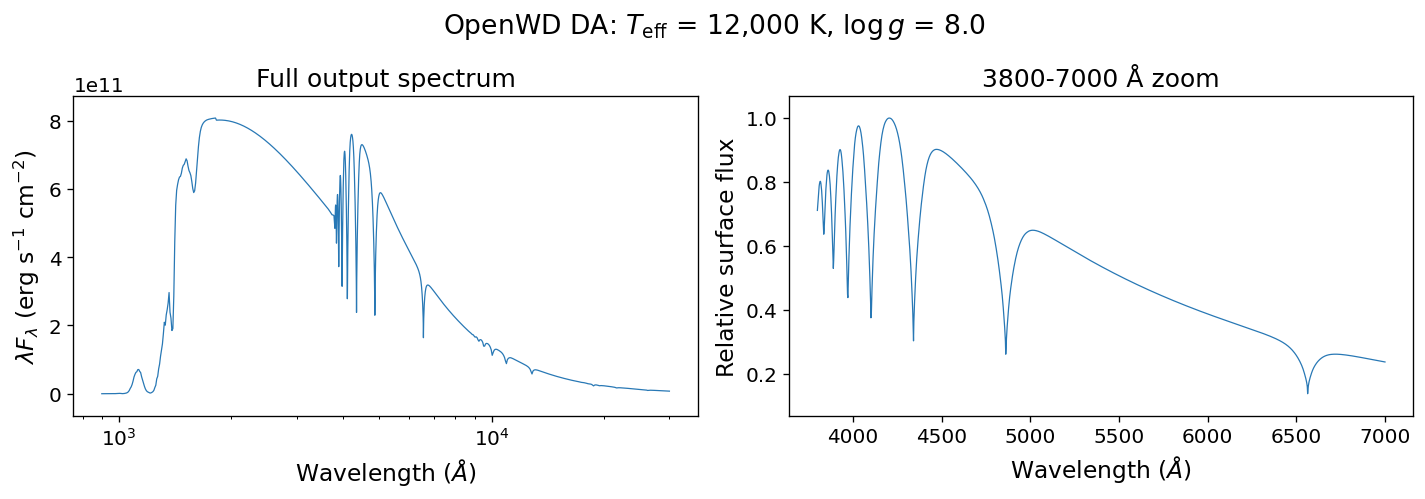

In [7]:
wave = spectrum.wavelength_angstrom
flux = spectrum.surface_flux_lambda
zoom = (wave >= zoom_lower) & (wave <= zoom_upper)
relative_flux = flux[zoom] / np.max(flux[zoom])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(wave, wave * flux, color="#2878B5", linewidth=0.75)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"Wavelength ($\AA$)")
axes[0].set_ylabel(r"$\lambda F_\lambda$ (erg s$^{-1}$ cm$^{-2}$)")
axes[0].set_title("Full output spectrum")
axes[0].margins(y=0.08)

axes[1].plot(wave[zoom], relative_flux, color="#2878B5", linewidth=0.75)
axes[1].set_xlabel(r"Wavelength ($\AA$)")
axes[1].set_ylabel("Relative surface flux")
axes[1].set_title(
    f"{zoom_lower:.0f}-{zoom_upper:.0f} Å zoom"
)
axes[1].margins(y=0.08)

fig.suptitle(
    f"OpenWD {MODEL}: "
    + r"$T_{\rm eff}$"
    + f" = {TEFF:,.0f} K, "
    + r"$\log g$"
    + f" = {LOGG:.1f}",
    fontsize=16,
)
fig.tight_layout()

if SAVE_FIGURE:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_base = OUTPUT_DIR / f"openwd_{MODEL.lower()}_example_spectrum"
    fig.savefig(figure_base.with_suffix(".png"), dpi=220, bbox_inches="tight")
    fig.savefig(figure_base.with_suffix(".pdf"), bbox_inches="tight")
    print(f"Saved {figure_base.with_suffix('.png')}")
    print(f"Saved {figure_base.with_suffix('.pdf')}")

plt.show()


## Try another WD

Change `MODEL`, `TEFF`, and `LOGG` in the control cell, then rerun from that cell downward. 

For example, try a 20,000 K pure-helium atmosphere with `MODEL="DB"`, `TEFF=20_000.0`, and `LOGG=8.0`. 


In [8]:
# Examples to copy into the control cell:
# MODEL, TEFF, LOGG = "DB", 20_000.0, 8.0
# MODEL, TEFF, LOGG = "DAB", 20_000.0, 8.0
# MODEL, TEFF, LOGG = "DZ", 15_300.0, 8.0
# DZ_ABUNDANCES = {"O": -5.61, "Mg": -6.24, "Ca": -6.88}
